# AE reconstruction — prescribed contour

Section 5.4 de l'article (`\subsection{Autoencoder Performance}`) et les histogrammes
par checkpoint de l'annexe. Porte sur les 14 AE a contour prescrit ; les variantes
`_ll` / `_ol` sont evaluees par `eval_ae_optimal.ipynb`.


In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# Always run from repo root (InferencePipelineAE uses paths relative to repo root).
# Le dossier du notebook doit entrer dans sys.path AVANT le chdir : sous nbclient le
# kernel n'y met que '', resolu dynamiquement au cwd courant, donc apres le chdir
# `import figstyle` ne trouve plus rien (contrairement a Jupyter interactif, qui y
# met le chemin absolu du notebook).
_NB_DIR = os.path.abspath('notebooks' if os.path.basename(os.getcwd()) != 'notebooks' else '.')
if _NB_DIR not in sys.path:
    sys.path.insert(0, _NB_DIR)

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.insert(0, 'src')

from omegaconf import open_dict

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline_ae import InferencePipelineAE


/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- style des figures de l'article (voir notebooks/figstyle.py) ---
# run= prefixe les fichiers, parce que ce notebook sert aussi bien sur les
# checkpoints a contour prescrit que sur les contours optimises.
import figstyle
figstyle.setup(run='ae')       # titles=True pour garder les suptitle en interactif


figstyle: style=paper.mplstyle  run=ae  titles=suppressed  ->  /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images


## 1. Dataset loading and normalisation

In [3]:
DATA_PATH  = 'dataset/ch4_rotated.npy'
SPLIT_PATH = 'dataset/split.npz'
CKPT_DIR   = 'checkpoints'
CACHE_DIR  = 'notebooks/cache'
N          = 128
DT         = 1.0

# Regularisation de l'inversion de Tikhonov utilisee pour evaluer la reconstruction.
# Alignee sur configs/training/surrogate_slae.yaml, que ckpt_utils.laplace_reg relit
# pour la phase 2 : les deux etages doivent inverser dans le meme regime.
ALPHA_T_INV = 7e-3
LAM_INV     = 3e-5


os.makedirs(CACHE_DIR, exist_ok=True)

U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')


Dataset: 8100 sims, Nt=150, 128×128


Train: 6480  Test: 1620


In [4]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation functions

In [5]:
def eval_ae(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 8) -> np.ndarray:
    """
    Reconstruit U via InferencePipelineAE et calcule le L2rel (%) sur le champ physique.
    Supporte LLAE et SLAE.
    """
    pipe = InferencePipelineAE.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    # Regularisation de l'inversion de Tikhonov. Le checkpoint AE n'en porte pas
    # (la phase 1 de SLAE n'inverse jamais), et le repli du pipeline laisse
    # l'inversion quasi nue. On prend les valeurs avec lesquelles le surrogate est
    # entraine et evalue, sinon les deux etages ne sont pas comparables.
    # Les contours _ol gardent les leurs, optimisees conjointement avec les poles.
    if not getattr(pipe.cfg.model, 'optimal_laplace', False):
        with open_dict(pipe.cfg):
            pipe.cfg.model.alpha_t = ALPHA_T_INV
            pipe.cfg.model.lam     = LAM_INV

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        U_batch   = np.stack([load_u(i) for i in batch_idx])   # (B, Nt, N, N)
        U_rec     = pipe.reconstruct(U_batch)                   # (B, Nt, N, N)

        for j in range(len(batch_idx)):
            denom = np.linalg.norm(U_batch[j])
            if denom >= 1e-12:
                l2rel_list.append(np.linalg.norm(U_rec[j] - U_batch[j]) / denom * 100.0)

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluation of all checkpoints

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if ((os.path.basename(p).startswith('llae_') or os.path.basename(p).startswith('slae_')) 
    and (os.path.basename(p).find('_ll') == -1 and os.path.basename(p).find('_ol') == -1))
])
print(f'{len(ckpt_paths)} AE checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda
14 AE checkpoints found:
  llae_ld128_K16_g0.01.ckpt
  llae_ld32_K16_g0.01.ckpt
  llae_ld64_K16_g0.0.ckpt
  llae_ld64_K16_g0.001.ckpt
  llae_ld64_K16_g0.01.ckpt
  llae_ld64_K32_g0.01.ckpt
  llae_ld64_K8_g0.01.ckpt
  slae_ld128_K16_g0.01.ckpt
  slae_ld32_K16_g0.01.ckpt
  slae_ld64_K16_g0.0.ckpt
  slae_ld64_K16_g0.001.ckpt
  slae_ld64_K16_g0.01.ckpt
  slae_ld64_K32_g0.01.ckpt
  slae_ld64_K8_g0.01.ckpt


In [7]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    data = np.load(cache_file, allow_pickle=True)
    return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

results = {}   # name → np.array L2rel (%)

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    model_type = 'llae' if name.startswith('llae') else 'slae'
    cache_file = _cache_path(name)

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}')
    else:
        print(f'[compute] {name}  [{model_type}]')
        try:
            l2 = eval_ae(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

Device: cuda

[cache]   llae_ld128_K16_g0.01
   median=2.87%  mean=3.09%  p90=4.34%  n=1620
[cache]   llae_ld32_K16_g0.01
   median=3.37%  mean=3.79%  p90=5.55%  n=1620
[cache]   llae_ld64_K16_g0.0
   median=3.19%  mean=3.55%  p90=5.21%  n=1620
[cache]   llae_ld64_K16_g0.001
   median=3.24%  mean=3.57%  p90=5.11%  n=1620
[cache]   llae_ld64_K16_g0.01
   median=3.13%  mean=3.41%  p90=4.99%  n=1620
[cache]   llae_ld64_K32_g0.01
   median=3.12%  mean=3.47%  p90=5.08%  n=1620
[cache]   llae_ld64_K8_g0.01
   median=3.28%  mean=3.59%  p90=5.18%  n=1620
[cache]   slae_ld128_K16_g0.01
   median=7.99%  mean=8.41%  p90=10.46%  n=1620
[cache]   slae_ld32_K16_g0.01
   median=10.76%  mean=11.15%  p90=14.78%  n=1620
[cache]   slae_ld64_K16_g0.0
   median=7.79%  mean=8.12%  p90=9.92%  n=1620
[cache]   slae_ld64_K16_g0.001
   median=7.83%  mean=8.28%  p90=10.37%  n=1620
[cache]   slae_ld64_K16_g0.01
   median=8.93%  mean=9.54%  p90=12.58%  n=1620
[cache]   slae_ld64_K32_g0.01
   median=8.36%  mean=9.2

In [8]:
import re
from collections import defaultdict
from matplotlib.lines import Line2D

_CKPT_PAT = re.compile(r'^(slae|llae)_ld(\d+)_K(\d+)_g([0-9.]+)')

def _pretty_name(name: str) -> str:
    m = _CKPT_PAT.match(name)
    if not m:
        return name
    model = m.group(1).upper()
    ld    = m.group(2)
    K     = m.group(3)
    g     = float(m.group(4))
    g_str = str(int(g)) if g == int(g) else str(g).rstrip('0')
    return f'{model}  d={ld}, K={K}, γ={g_str}'

colors = figstyle.PALETTE                # cles 'slae' / 'llae' — voir notebooks/figstyle.py

pat = re.compile(r'^(?P<ae>llae|slae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<suffix>.*)$')

def _fmt_label(v):
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)

# Build rows for ablation plots
ae_rows = []
for name in results:
    m = pat.match(name)
    if not m:
        continue
    ae_rows.append({
        'name'  : name,
        'ae'    : m.group('ae'),
        'ld'    : int(m.group('ld')),
        'K'     : int(m.group('K')),
        'gamma' : float(m.group('g')),
        'suffix': m.group('suffix') or '',
    })

def _select_rows(ae_type, var_name, fixed):
    rows = [r for r in ae_rows
            if r['ae'] == ae_type and all(r[k] == v for k, v in fixed.items())]
    return sorted(rows, key=lambda r: r[var_name])

def _plot_family(ax, rows, var_name, xlabel, title):
    if not rows:
        ax.set_title(f"{title}\n(no matching checkpoints)")
        ax.axis('off')
        return

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(results[r['name']].tolist())

    xs_vals   = sorted(groups.keys())
    datasets  = [groups[v] for v in xs_vals]
    positions = list(range(len(xs_vals)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.65, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');   parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');    parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)
    parts['cbars'].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([_fmt_label(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')


## 4. Laplace poles $s_k$ and inversion regularization

Read directly from the raw checkpoints, one panel per checkpoint:

- **LLAE** — the poles live in the model (`model.laplace.*` in the `state_dict`):
  current poles, their init buffers, and $\alpha_t$ / $\lambda$ taken from
  `log_alpha_t` / `log_lam` when `learnable_laplace=True`, from the frozen buffers otherwise.
- **SLAE** — the transform is applied in the data domain: the poles are the checkpoint's
  `s_list` (init reference: `gamma_init` + truncated FFT contour), and $(\alpha_t, \lambda)$
  come from the offline optimisation file when `optimal_laplace=True`
  (same logic as `InferencePipelineAE._reconstruct_slae`).


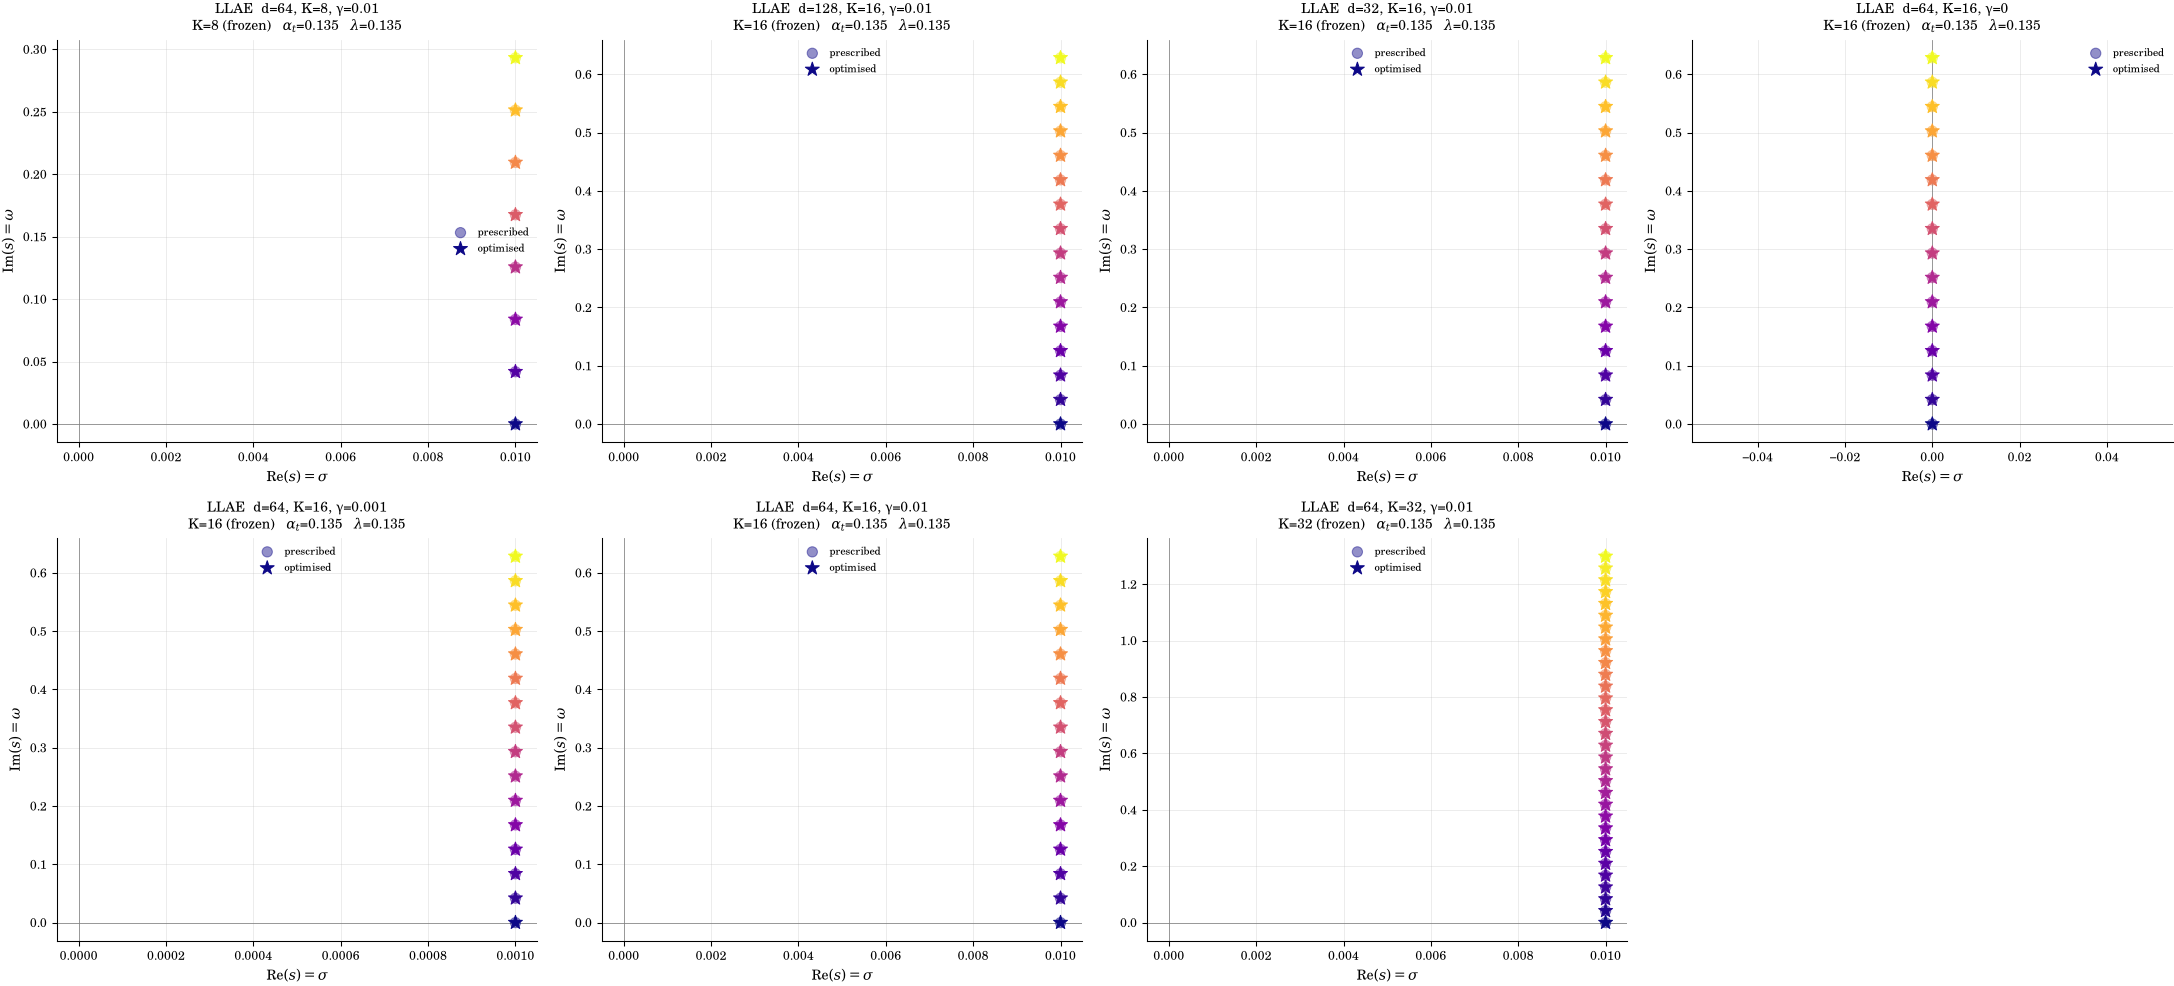

  ↳ article/images/ae_contour_poles_llae.pdf


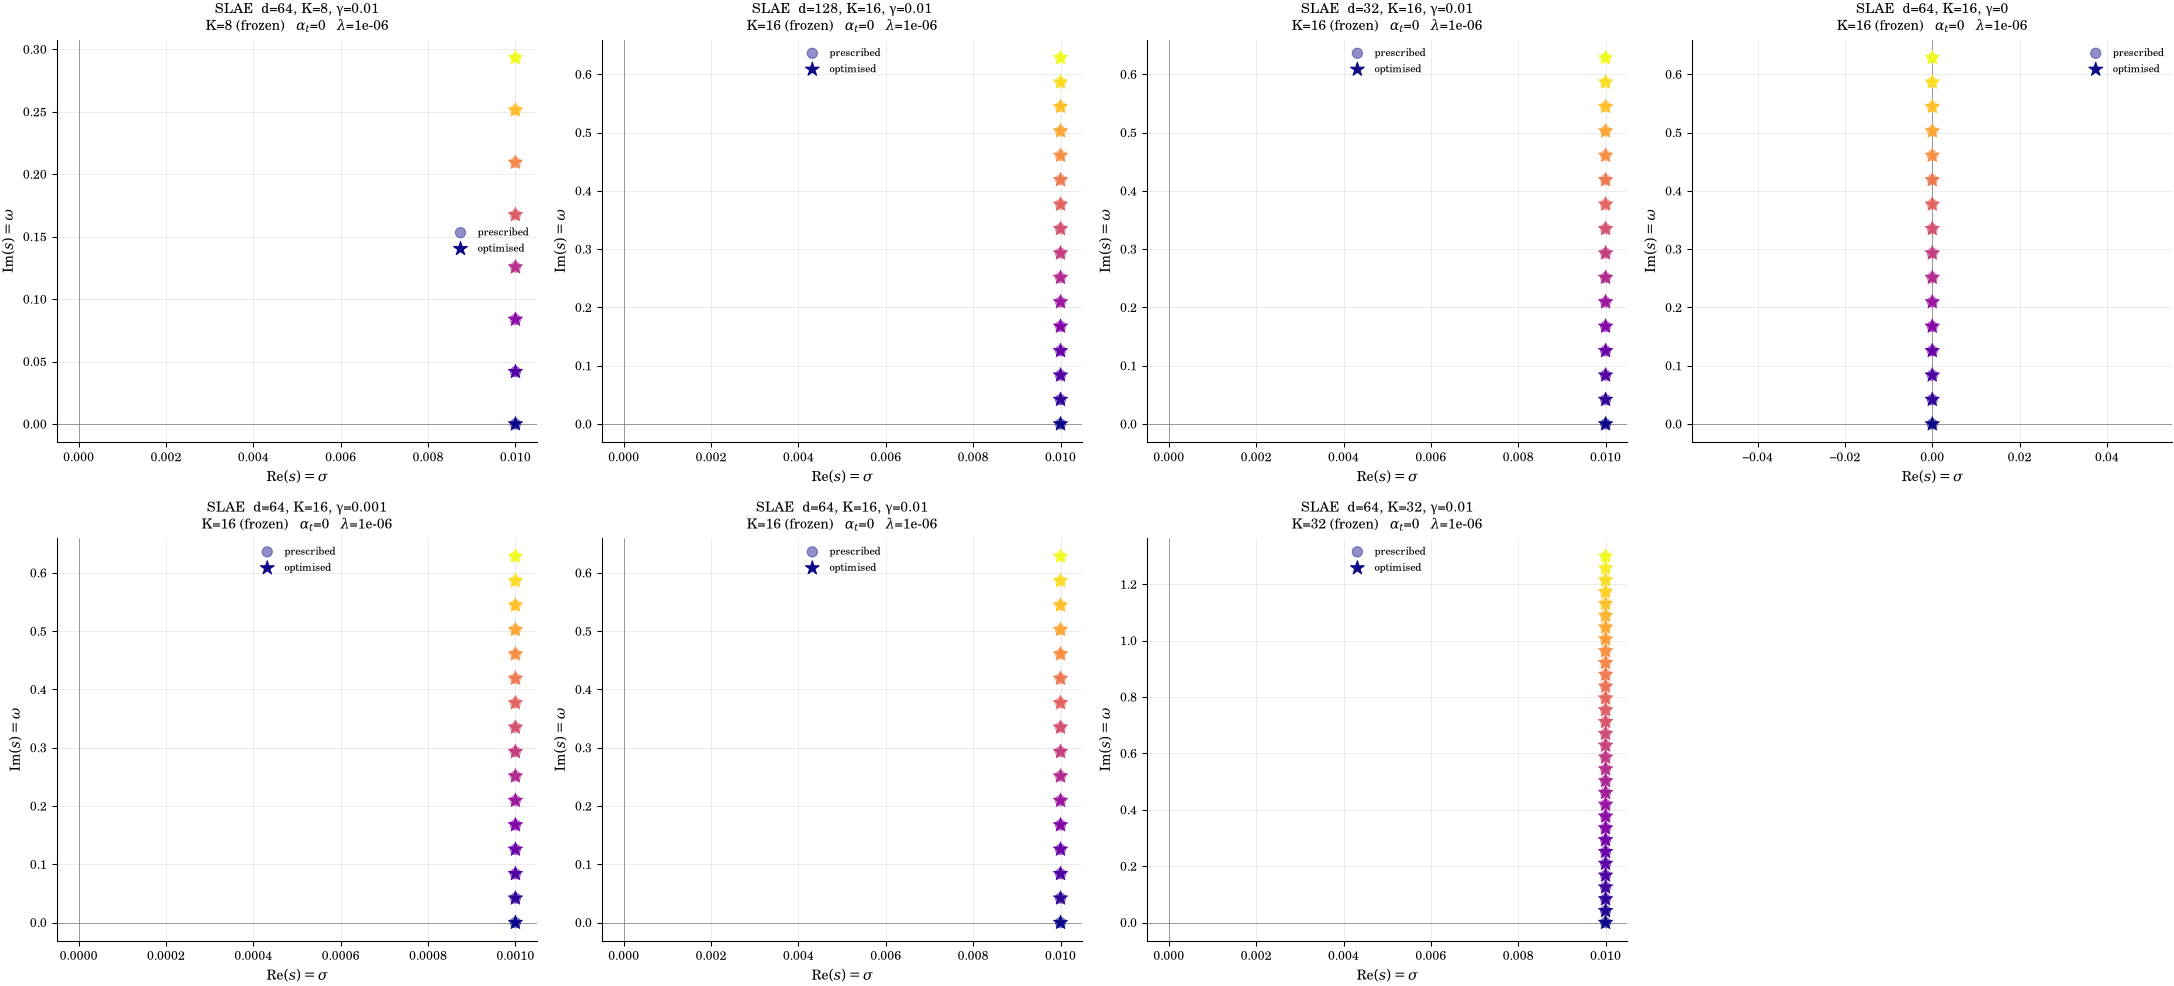

  ↳ article/images/ae_contour_poles_slae.pdf


In [9]:
# ── Laplace poles s_k + regularization used by the AE checkpoints ────────
pole_info = {}   # name → dict

for ckpt_path in ckpt_paths:
    name  = os.path.splitext(os.path.basename(ckpt_path))[0]
    raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    cfg_m = raw['hyper_parameters']['cfg'].model

    if cfg_m.name == 'llae':
        sd        = raw['state_dict']
        learnable = bool(getattr(cfg_m, 'learnable_laplace', False))
        s_cur  = (sd['model.laplace.s_re'] + 1j * sd['model.laplace.s_im']).numpy()
        s_init = (sd['model.laplace._s_init_re'] + 1j * sd['model.laplace._s_init_im']).numpy()
        if learnable:
            alpha_t = float(sd['model.laplace.log_alpha_t'].exp())
            lam     = float(sd['model.laplace.log_lam'].exp())
        else:
            alpha_t = float(sd['model.laplace._alpha_t_fixed'])
            lam     = float(sd['model.laplace._lam_fixed'])
    else:  # slae
        learnable = False
        K      = int(cfg_m.K)
        dt     = float(raw.get('dt', DT))
        s_cur  = raw['s_list'].astype(np.complex128)
        s_init = cfg_m.gamma_init + 1j * 2 * np.pi * np.fft.rfftfreq(Nt_full, d=dt)[:K]
        alpha_t = float(getattr(cfg_m, 'alpha_t', 0.0))
        lam     = float(getattr(cfg_m, 'lam',     1e-6))
        if getattr(cfg_m, 'optimal_laplace', False):
            opt_path = getattr(cfg_m, 'optimal_laplace_path', None)
            if opt_path and os.path.exists(opt_path):
                opt = torch.load(opt_path, map_location='cpu', weights_only=False)
                alpha_t, lam = float(opt['alpha_t']), float(opt['lam'])
            else:
                alpha_t = lam = None   # optimisation file missing locally

    pole_info[name] = dict(ae=str(cfg_m.name), s_cur=np.asarray(s_cur),
                           s_init=np.asarray(s_init), alpha_t=alpha_t, lam=lam,
                           learnable=learnable)
    del raw
gc.collect()

for family in ('llae', 'slae'):
    fam_names = sorted(
        [n for n in pole_info if pole_info[n]['ae'] == family],
        key=lambda n: (len(pole_info[n]['s_cur']), n),
    )
    if not fam_names:
        print(f'No {family} checkpoint found.')
        continue

    ncols = min(4, len(fam_names))
    nrows = int(np.ceil(len(fam_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows), squeeze=False)
    for ax in axes.flat[len(fam_names):]:
        ax.axis('off')

    for ax, n in zip(axes.flat, fam_names):
        info = pole_info[n]
        s_cur, s_ini = info['s_cur'], info['s_init']
        K = len(s_cur)
        c = np.arange(K)
        for a, b in zip(s_ini, s_cur):
            ax.plot([a.real, b.real], [a.imag, b.imag], color='gray', lw=0.6, alpha=0.5, zorder=1)
        ax.scatter(s_ini.real, s_ini.imag, c=c, cmap='plasma', s=45, marker='o',
                   alpha=0.45, zorder=3, label='prescribed')
        ax.scatter(s_cur.real, s_cur.imag, c=c, cmap='plasma', s=90, marker='*',
                   zorder=4, label='optimised')
        ax.axvline(0, color='gray', lw=0.5)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel(r'Re$(s) = \sigma$')
        ax.set_ylabel(r'Im$(s) = \omega$')
        tag = 'learnable' if info['learnable'] else 'frozen'
        if info['alpha_t'] is None:
            reg = r'$\alpha_t$, $\lambda$: n/a (opti file missing)'
        else:
            reg = rf'$\alpha_t$={info["alpha_t"]:.3g}   $\lambda$={info["lam"]:.3g}'
        ax.set_title(_pretty_name(n) + '\n' + rf'K={K} ({tag})   ' + reg, fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(f'{family.upper()} — Laplace poles $s_k$ and inversion regularization',
                 fontweight='bold')
    fig.tight_layout()
    plt.show()
    figstyle.save("contour_poles_" + str(family).replace("Model", "").lower())


## 5. Histograms per checkpoint

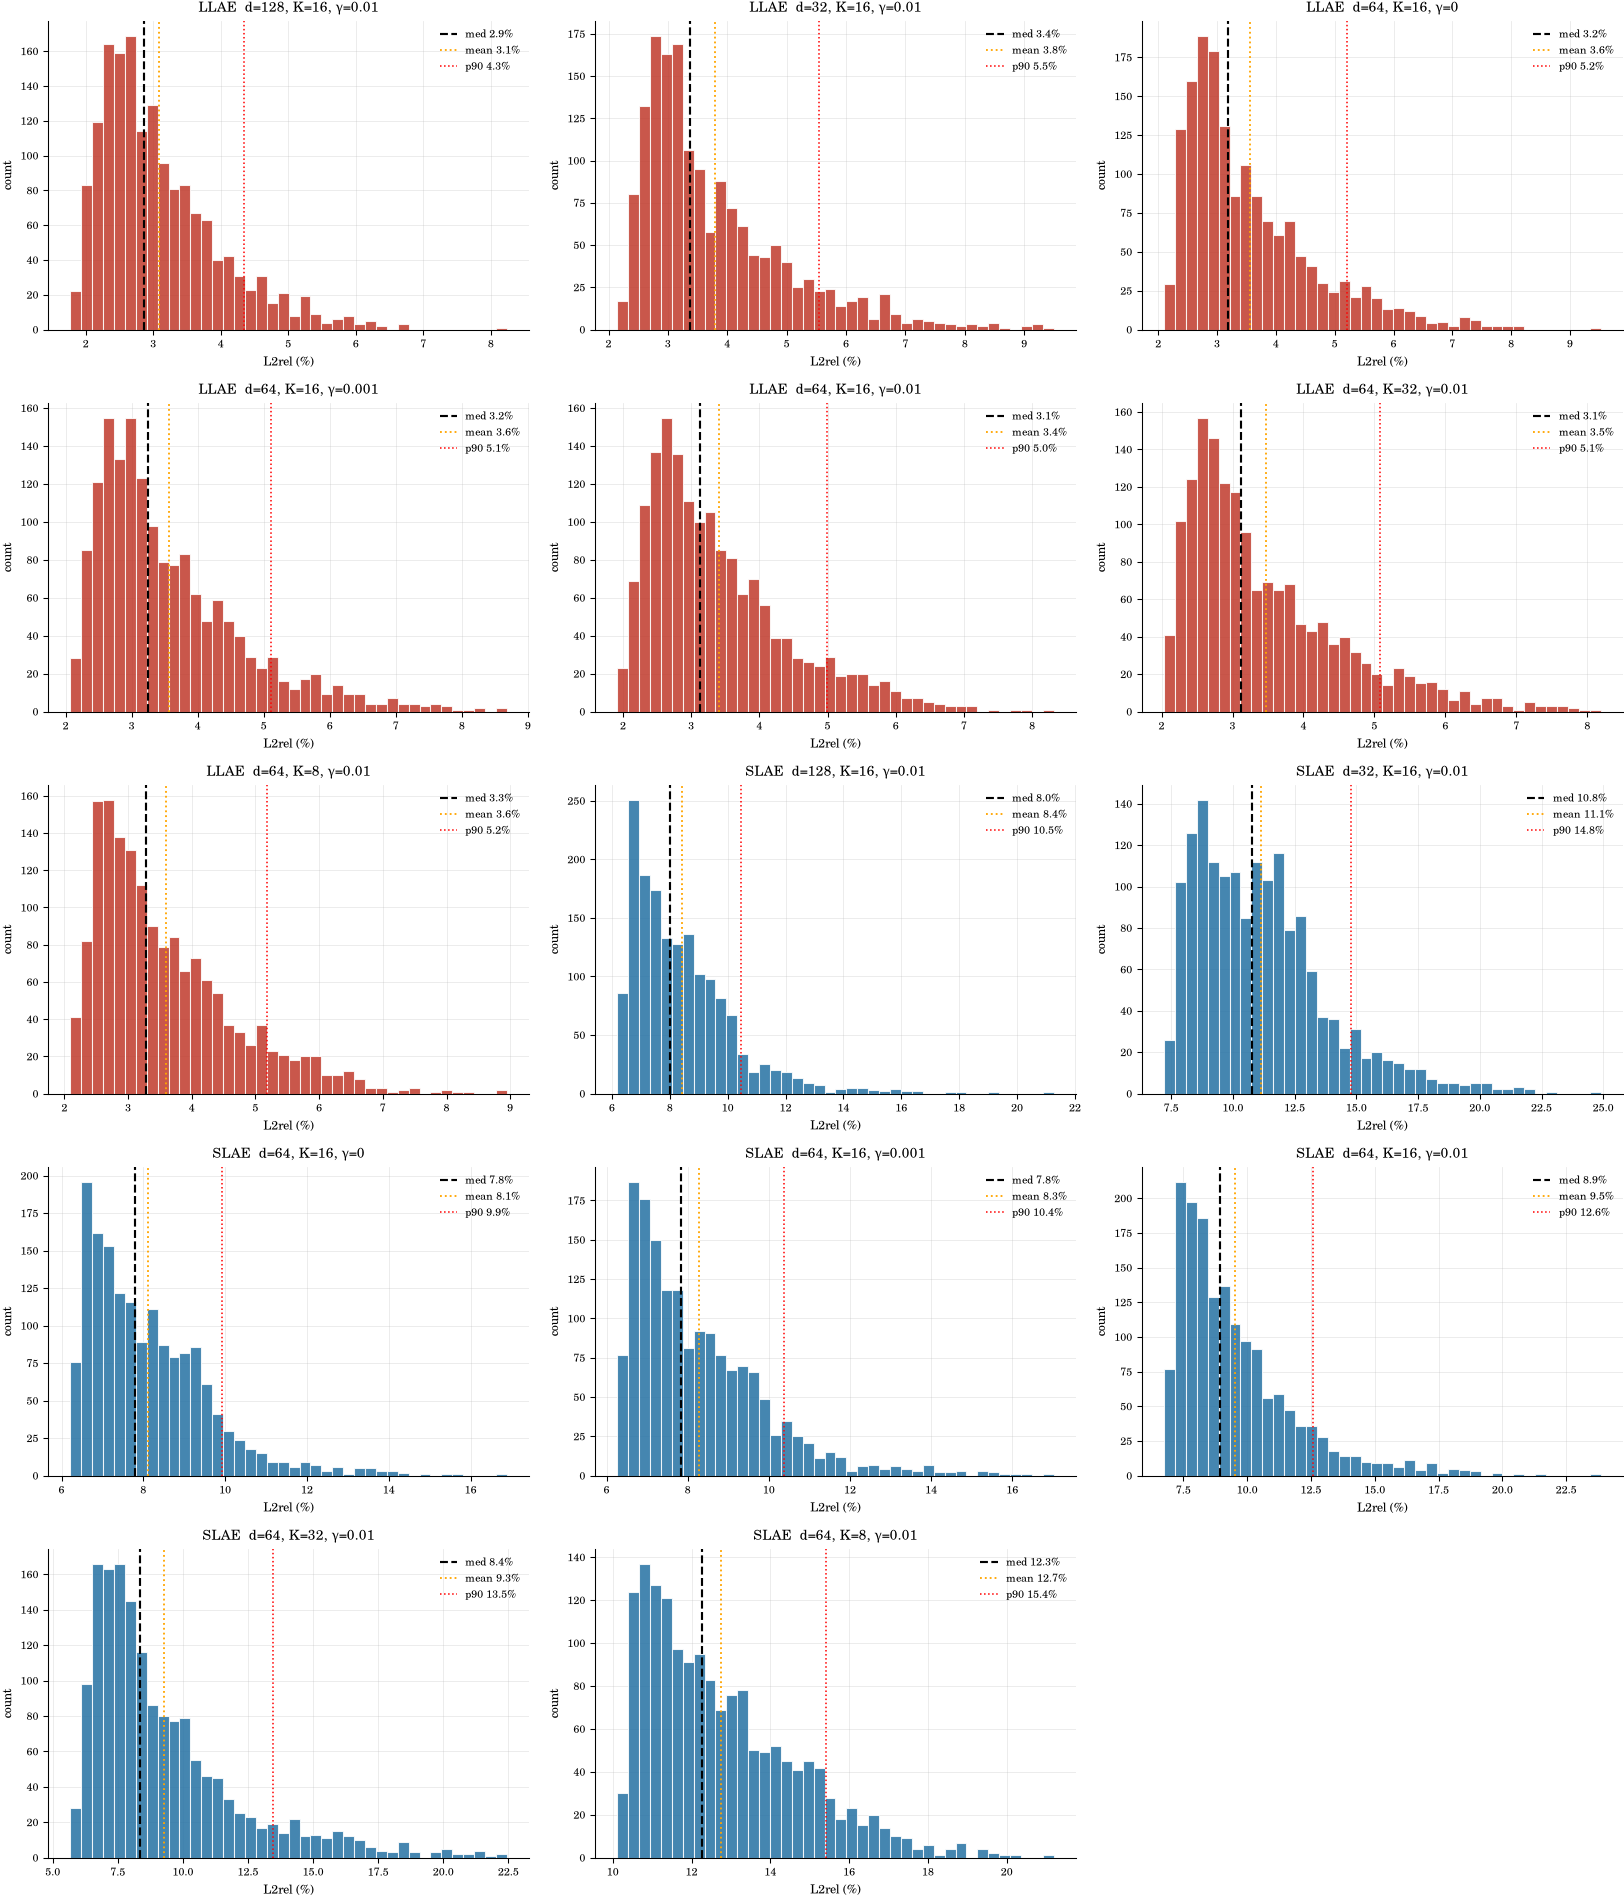

  ↳ article/images/ae_hist_grid.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/ae_hist_grid.pdf')

In [10]:
names  = list(results.keys())
n_ckpt = len(names)
ncols  = 3
nrows  = (n_ckpt + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

colors = figstyle.PALETTE                # cles 'slae' / 'llae' — voir notebooks/figstyle.py

for ax, name in zip(axes, names):
    l2      = results[name]
    mtype   = 'llae' if name.startswith('llae') else 'slae'
    median  = np.median(l2)
    mean    = np.mean(l2)
    p90     = np.percentile(l2, 90)

    ax.hist(l2, bins=40, color=colors[mtype], edgecolor='white', alpha=0.85)
    ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
    ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
    ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
    ax.set_title(_pretty_name(name), fontsize=9)
    ax.set_xlabel('L2rel (%)', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes[n_ckpt:]:
    ax.set_visible(False)

fig.suptitle('L2rel on physical field U — AE reconstruction (test set)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("hist_grid")


## 6. Median comparison

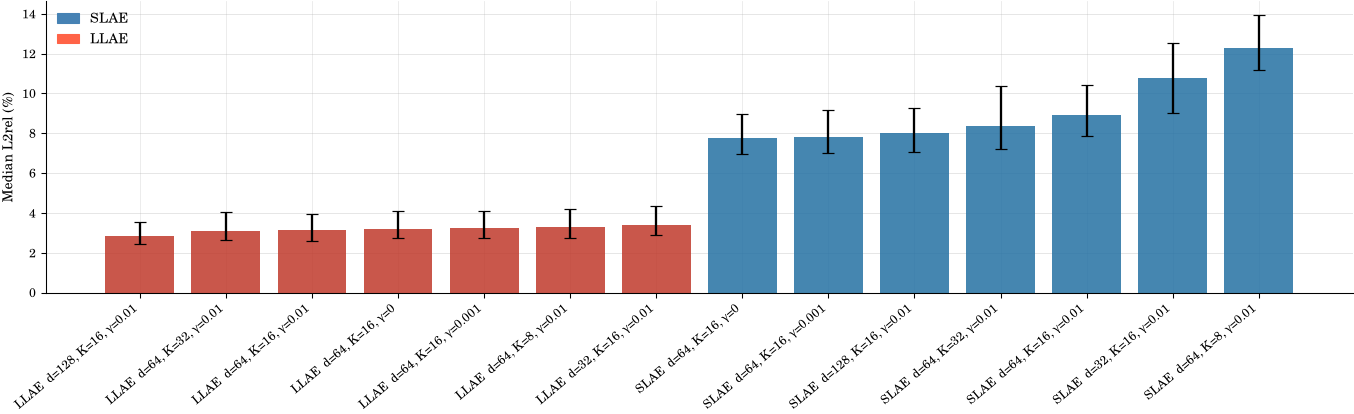

  ↳ article/images/ae_bar_all.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/ae_bar_all.pdf')

In [11]:
medians = {n: float(np.median(v)) for n, v in results.items()}
p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

sorted_names = sorted(medians, key=lambda n: medians[n])
bar_colors   = [colors['llae' if n.startswith('llae') else 'slae'] for n in sorted_names]

fig, ax = plt.subplots(figsize=(max(8, n_ckpt * 0.9), 4))
x = np.arange(len(sorted_names))

bars = ax.bar(x, [medians[n] for n in sorted_names], color=bar_colors, alpha=0.85, zorder=2)

# IQR error bars
yerr_low  = [medians[n] - p25[n] for n in sorted_names]
yerr_high = [p75[n] - medians[n] for n in sorted_names]
ax.errorbar(x, [medians[n] for n in sorted_names],
            yerr=[yerr_low, yerr_high],
            fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([_pretty_name(n) for n in sorted_names], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Median L2rel (%)')
ax.grid(axis='y', alpha=0.4, zorder=0)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='SLAE'),
    Patch(color='tomato',    label='LLAE'),
], fontsize=9)

fig.tight_layout()
plt.show()
figstyle.save("bar_all")


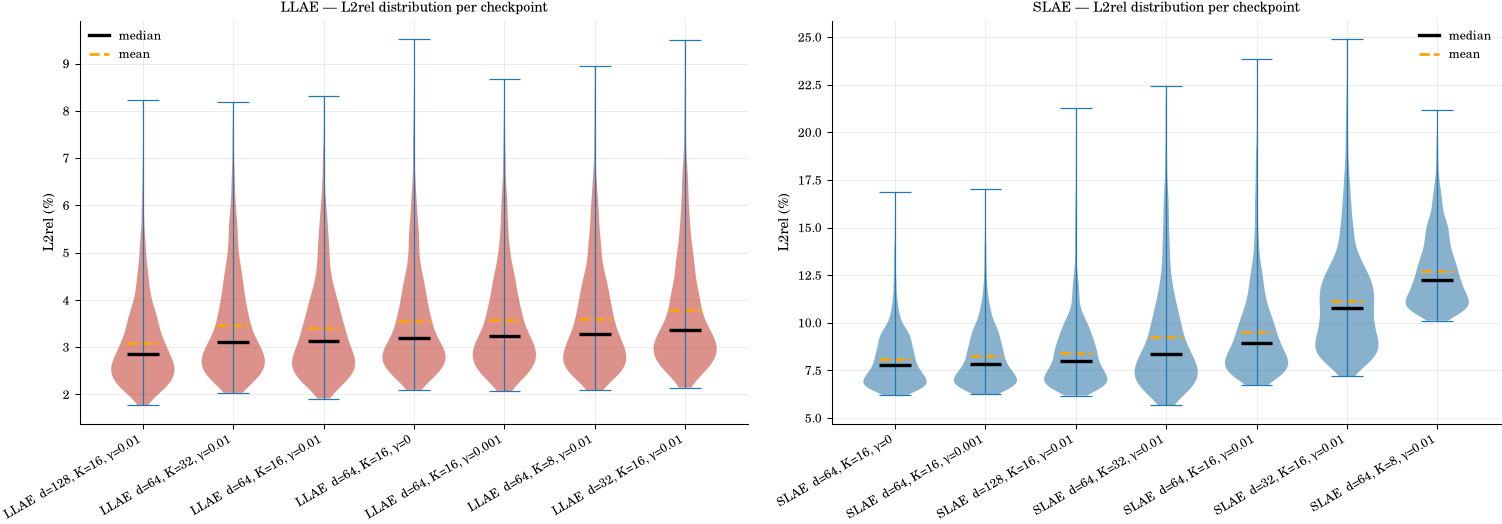

  ↳ article/images/ae_violins_all.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/ae_violins_all.pdf')

In [12]:
# Violon par famille : distribution complète du L2rel (%) pour chaque checkpoint
# (remplace le bar chart median ± IQR par deux sous-figures LLAE / SLAE)
from matplotlib.lines import Line2D

def _violin_family(ax, family, title):
    fam_names = sorted(
        [n for n in results if n.startswith(family)],
        key=lambda n: np.median(results[n]),
    )
    if not fam_names:
        ax.set_title(f'{title}\n(no matching checkpoints)')
        ax.axis('off')
        return

    datasets  = [results[n] for n in fam_names]
    positions = list(range(len(fam_names)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.7, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[family])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');   parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');    parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)
    parts['cbars'].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([_pretty_name(n) for n in fam_names], rotation=30, ha='right', fontsize=8)
    ax.set_xlim(-0.7, len(fam_names) - 0.3)
    ax.set_ylabel('L2rel (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='y')
    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,                    label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--',    label='mean'),
    ], fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_violin_family(axes[0], 'llae', 'LLAE — L2rel distribution per checkpoint')
_violin_family(axes[1], 'slae', 'SLAE — L2rel distribution per checkpoint')

fig.suptitle('Checkpoint comparison — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("violins_all")


## 7. Summary 

In [13]:
print(f"{'Checkpoint':<40}  {'type':^5}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
print('-' * 82)
for n in sorted(results, key=lambda n: np.median(results[n])):
    l2    = results[n]
    mtype = 'llae' if n.startswith('llae') else 'slae'
    print(f'{n:<40}  {mtype:^5}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  {np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Checkpoint                                type     median      mean       p90      n
----------------------------------------------------------------------------------
llae_ld128_K16_g0.01                      llae      2.87%     3.09%     4.34%   1620
llae_ld64_K32_g0.01                       llae      3.12%     3.47%     5.08%   1620
llae_ld64_K16_g0.01                       llae      3.13%     3.41%     4.99%   1620
llae_ld64_K16_g0.0                        llae      3.19%     3.55%     5.21%   1620
llae_ld64_K16_g0.001                      llae      3.24%     3.57%     5.11%   1620
llae_ld64_K8_g0.01                        llae      3.28%     3.59%     5.18%   1620
llae_ld32_K16_g0.01                       llae      3.37%     3.79%     5.55%   1620
slae_ld64_K16_g0.0                        slae      7.79%     8.12%     9.92%   1620
slae_ld64_K16_g0.001                      slae      7.83%     8.28%    10.37%   1620
slae_ld128_K16_g0.01                      slae      7.99%     8.41%

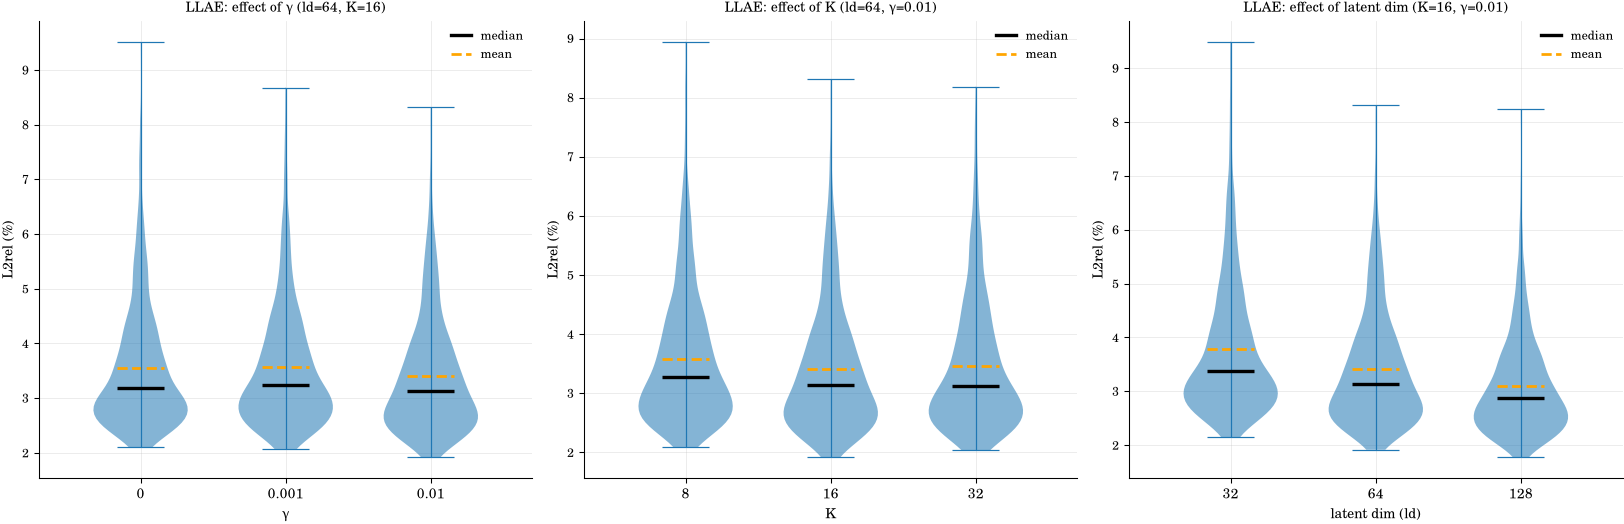

  ↳ article/images/ae_ablation_llae.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/ae_ablation_llae.pdf')

In [14]:
rows_gamma = _select_rows('llae', 'gamma', {'ld': 64, 'K': 16})
rows_K     = _select_rows('llae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld    = _select_rows('llae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_plot_family(axes[0], rows_gamma, 'gamma', 'γ',               'LLAE: effect of γ (ld=64, K=16)')
_plot_family(axes[1], rows_K,     'K',     'K',               'LLAE: effect of K (ld=64, γ=0.01)')
_plot_family(axes[2], rows_ld,    'ld',    'latent dim (ld)', 'LLAE: effect of latent dim (K=16, γ=0.01)')

fig.suptitle('LLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("ablation_llae")


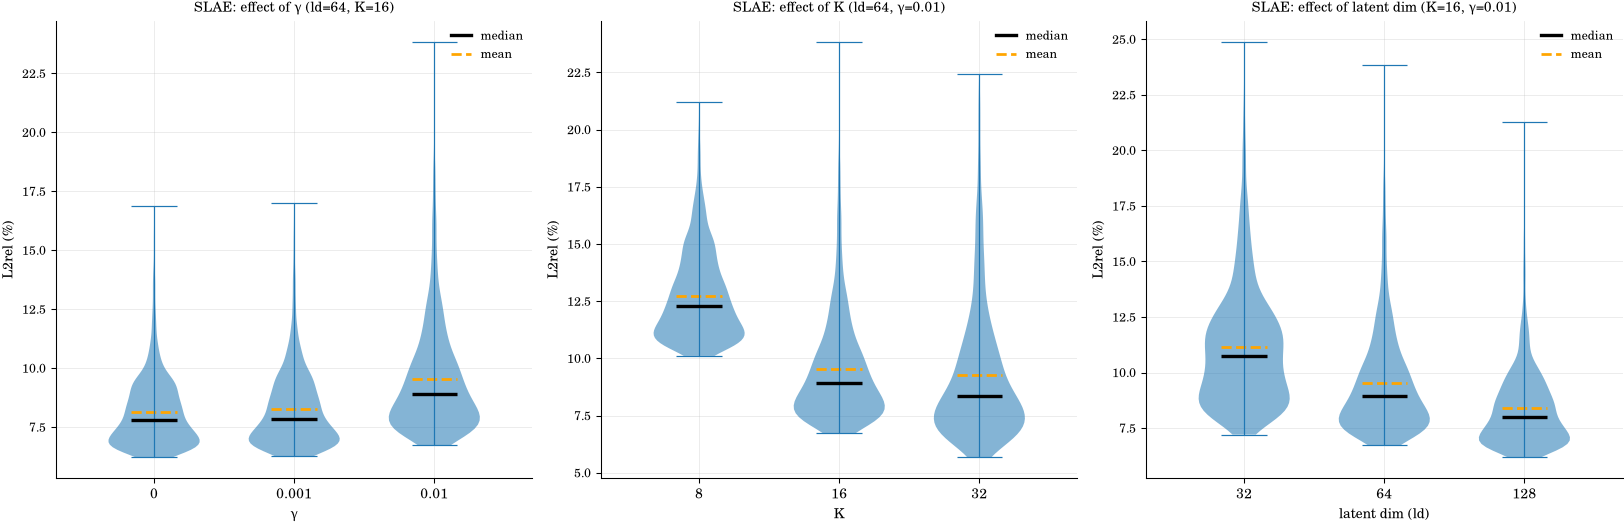

  ↳ article/images/ae_ablation_slae.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/ae_ablation_slae.pdf')

In [15]:
rows_gamma_s = _select_rows('slae', 'gamma', {'ld': 64, 'K': 16})
rows_K_s     = _select_rows('slae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld_s    = _select_rows('slae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_plot_family(axes[0], rows_gamma_s, 'gamma', 'γ',               'SLAE: effect of γ (ld=64, K=16)')
_plot_family(axes[1], rows_K_s,     'K',     'K',               'SLAE: effect of K (ld=64, γ=0.01)')
_plot_family(axes[2], rows_ld_s,    'ld',    'latent dim (ld)', 'SLAE: effect of latent dim (K=16, γ=0.01)')

fig.suptitle('SLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("ablation_slae")


## 6.2 SLAE — erreur par fréquence de Laplace

Erreur relative mesurée **dans le domaine de Laplace**, fréquence par fréquence,
pour les checkpoints SLAE. Pendant SLAE de la décomposition POD par fréquence
(`pod_rec_per_freq`) : c'est la comparaison des deux qui montre que SLAE encode
mieux chaque fréquence sans pour autant mieux reconstruire le champ spatial,
la régularisation de Tikhonov amortissant uniformément le bénéfice.


In [16]:
from laplace_surrogate.laplace_transform.forward import laplace_forward_tik


def _strip_model_prefix(state_dict):
    """Retire le prefixe 'model.' ajoute par Lightning."""
    return {k[len('model.'):]: v for k, v in state_dict.items() if k.startswith('model.')}


def eval_slae_per_freq(ckpt_path: str, idx_list: list, device='cpu') -> np.ndarray:
    """(n_samples, K) : L2rel (%) dans le domaine de Laplace, a chaque frequence k."""
    ckpt      = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg_model = ckpt['hyper_parameters']['cfg']['model']
    s_list_np = ckpt['s_list']
    K         = len(s_list_np)
    dt        = float(ckpt.get('dt', DT))

    from laplace_surrogate.models.slae import SLAE
    model = SLAE(N=N, latent_dim=ckpt['latent_dim'],
                 beta=cfg_model.get('beta', 0.01),
                 freq_L=cfg_model.get('freq_L', 8))
    model.load_state_dict(_strip_model_prefix(ckpt['state_dict']))
    model.eval().to(device)

    s_tensor   = torch.tensor(s_list_np, dtype=torch.complex128)
    lap_mean_t = torch.tensor(ckpt['lap_mean'], dtype=torch.float32, device=device)
    lap_std_t  = torch.tensor(ckpt['lap_std'],  dtype=torch.float32, device=device)
    fr_t       = torch.tensor(np.arange(K, dtype=np.float32) / max(K - 1, 1), device=device)

    l2rel_per_sample = []
    with torch.no_grad():
        for idx in tqdm(idx_list, desc=os.path.basename(ckpt_path), leave=False):
            U_phys = load_u(idx)
            Nt     = U_phys.shape[0]

            u_flat   = torch.tensor(U_phys.reshape(Nt, N * N).T, dtype=torch.float64)
            U_lap    = laplace_forward_tik(u_flat, s_tensor, dt, 'trap')
            U_lap_np = U_lap.numpy().reshape(N, N, K)
            del u_flat, U_lap

            u_batch  = np.stack([np.stack([U_lap_np[:, :, k].real,
                                           U_lap_np[:, :, k].imag], axis=0)
                                 for k in range(K)]).astype(np.float32)
            u_b_norm = (torch.tensor(u_batch, device=device) - lap_mean_t) / lap_std_t
            u_rec_norm, _ = model(u_b_norm, fr_t)
            del u_b_norm
            u_rec_np = (u_rec_norm * lap_std_t + lap_mean_t).cpu().numpy()
            del u_rec_norm

            l2k = np.zeros(K)
            for k in range(K):
                U_k     = U_lap_np[:, :, k]
                U_rec_k = u_rec_np[k, 0] + 1j * u_rec_np[k, 1]
                denom   = np.linalg.norm(U_k)
                if denom >= 1e-12:
                    l2k[k] = np.linalg.norm(U_rec_k - U_k) / denom * 100.0
            del U_lap_np, u_batch, u_rec_np
            l2rel_per_sample.append(l2k)

    model.cpu(); del model
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.stack(l2rel_per_sample)   # (n_samples, K)


N_FREQ_EVAL   = 200
freq_eval_idx = test_idx[:N_FREQ_EVAL]

# Seulement les SLAE deja retenus par le filtre du notebook (contours prescrits).
slae_ckpts = [p for p in ckpt_paths if os.path.basename(p).startswith('slae')]

freq_results = {}   # name -> (n_samples, K)
for ckpt_path in slae_ckpts:
    name  = os.path.splitext(os.path.basename(ckpt_path))[0]
    cfile = os.path.join(CACHE_DIR, f'perfreq_{name}.npz')
    if os.path.exists(cfile) and \
       float(np.load(cfile)['ckpt_mtime']) == os.path.getmtime(ckpt_path):
        freq_results[name] = np.load(cfile)['freq']
        print(f'[cache]   per-freq {name}')
    else:
        print(f'[compute] per-freq {name}')
        freq_results[name] = eval_slae_per_freq(ckpt_path, freq_eval_idx, device=device)
        np.savez(cfile, freq=freq_results[name],
                 ckpt_mtime=np.float64(os.path.getmtime(ckpt_path)))

print(f'\n{len(freq_results)} checkpoint(s) SLAE evalues par frequence.')


[cache]   per-freq slae_ld128_K16_g0.01
[cache]   per-freq slae_ld32_K16_g0.01
[cache]   per-freq slae_ld64_K16_g0.0
[cache]   per-freq slae_ld64_K16_g0.001
[cache]   per-freq slae_ld64_K16_g0.01
[cache]   per-freq slae_ld64_K32_g0.01
[cache]   per-freq slae_ld64_K8_g0.01

7 checkpoint(s) SLAE evalues par frequence.


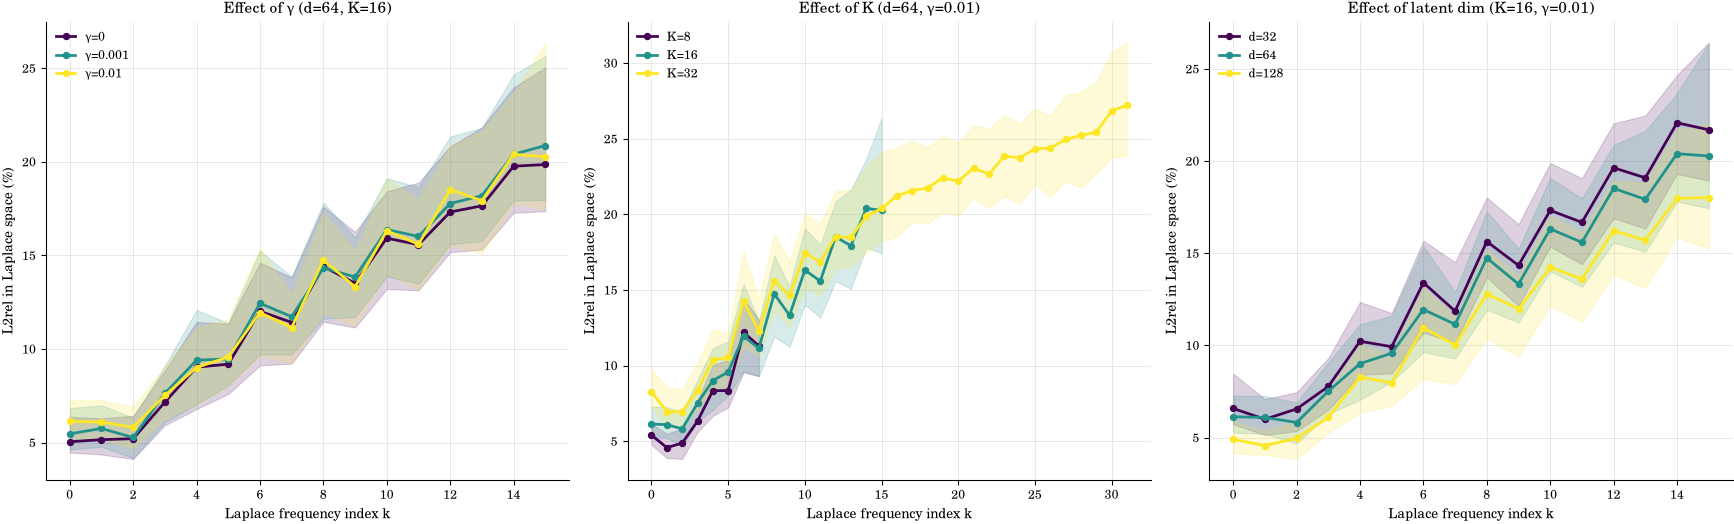

  ↳ article/images/ae_per_freq_slae.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/ae_per_freq_slae.pdf')

In [17]:
def _plot_freq_family(ax, rows, var_name, xlabel, title, freq_res):
    """Une courbe par valeur de `var_name` : mediane +/- IQR contre l'indice k."""
    cmap   = plt.cm.viridis
    values = sorted(set(r[var_name] for r in rows))
    norm   = plt.Normalize(vmin=0, vmax=max(len(values) - 1, 1))

    plotted = False
    for i, val in enumerate(values):
        matching = [r for r in rows if r[var_name] == val and r['name'] in freq_res]
        if not matching:
            continue
        mat     = freq_res[matching[0]['name']]      # (n_samples, K)
        K       = mat.shape[1]
        ks      = np.arange(K)
        color   = cmap(norm(i))
        ax.fill_between(ks, np.percentile(mat, 25, axis=0),
                        np.percentile(mat, 75, axis=0), alpha=0.18, color=color)
        ax.plot(ks, np.median(mat, axis=0), marker='o', markersize=4, linewidth=1.8,
                color=color, label=f'{xlabel}={_fmt_label(val)}')
        plotted = True

    if not plotted:
        ax.set_title(f'{title}\n(aucun checkpoint)'); ax.axis('off'); return

    ax.set_xlabel('Laplace frequency index k')
    ax.set_ylabel('L2rel in Laplace space (%)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.35)


rows_gamma_sf = _select_rows('slae', 'gamma', {'ld': 64, 'K': 16})
rows_K_sf     = _select_rows('slae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld_sf    = _select_rows('slae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_plot_freq_family(axes[0], rows_gamma_sf, 'gamma', 'γ',
                  'Effect of γ (d=64, K=16)', freq_results)
_plot_freq_family(axes[1], rows_K_sf, 'K', 'K',
                  'Effect of K (d=64, γ=0.01)', freq_results)
_plot_freq_family(axes[2], rows_ld_sf, 'ld', 'd',
                  'Effect of latent dim (K=16, γ=0.01)', freq_results)

fig.suptitle(f'SLAE — L2rel per Laplace frequency ({N_FREQ_EVAL} test samples, median ± IQR)',
             fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("per_freq_slae")


## 8. Inference latency benchmark

Per-sample AE reconstruction latency at `bs=1` (10 warm-up / 50 timed runs), measuring the
full round-trip `U(t) → encode → [Laplace / inverse] → decode → Û(t)` on one simulation.

In [18]:
import benchmark   # methodologie commune a tous les notebooks

# Single benchmark sample (bs=1), reused for every checkpoint
U_bench = load_u(test_idx[0])[None]        # (1, Nt, N, N)
print(f'Benchmark sample shape: {U_bench.shape}  |  device: {device}\n')

bench = {}   # name → dict(lat_med, lat_std)

for ckpt_path in ckpt_paths:
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        pipe = InferencePipelineAE.from_checkpoint(ckpt_path, device=device)

        def lat_fn():
            with torch.no_grad():
                pipe.reconstruct(U_bench)

        bench[name] = benchmark.measure(lat_fn, device, name=name)

        pipe.model.cpu(); del pipe
        if device == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

Benchmark sample shape: (1, 150, 128, 128)  |  device: cuda



Calcul des stats de normalisation sur le train set…


fit U_mean/std:   0%|          | 0/5184 [00:00<?, ?it/s]

fit U_mean/std:   0%|          | 14/5184 [00:00<00:38, 132.79it/s]

fit U_mean/std:   1%|          | 29/5184 [00:00<00:37, 136.81it/s]

...

slae_ld64_K16_g0.0                            lat=   22.8±  1.3 ms  flops=  31.1 G  mem=   518 MB  E=2650.4 mJ


slae_ld64_K16_g0.001                          lat=   23.6±  1.4 ms  flops=  31.1 G  mem=   518 MB  E=2672.7 mJ


slae_ld64_K16_g0.01                           lat=   22.9±  1.4 ms  flops=  31.1 G  mem=   518 MB  E=2664.9 mJ


slae_ld64_K32_g0.01                           lat=   28.1±  1.3 ms  flops=  62.2 G  mem=   794 MB  E=3230.1 mJ


slae_ld64_K8_g0.01                            lat=   20.7±  1.2 ms  flops=  15.5 G  mem=   404 MB  E=2091.7 mJ

Done.


checkpoint                                       lat (ms)       ±   FLOPs (G)   mem (MB)    E (mJ)
--------------------------------------------------------------------------------------------------
SLAE  d=64, K=8, γ=0.01                              20.7     1.2        15.5        404    2091.7
SLAE  d=64, K=16, γ=0                                22.8     1.3        31.1        518    2650.4
SLAE  d=64, K=16, γ=0.01                             22.9     1.4        31.1        518    2664.9
SLAE  d=64, K=16, γ=0.001                            23.6     1.4        31.1        518    2672.7
SLAE  d=32, K=16, γ=0.01                             23.7     1.2        31.0        510    2711.7
SLAE  d=128, K=16, γ=0.01                            23.8     1.4        31.2        534    2615.4
LLAE  d=64, K=32, γ=0.01                             27.0     1.9        54.2        556    3286.3
LLAE  d=64, K=16, γ=0                                27.0     2.1        54.2        556    3353.9
LLAE  d=32

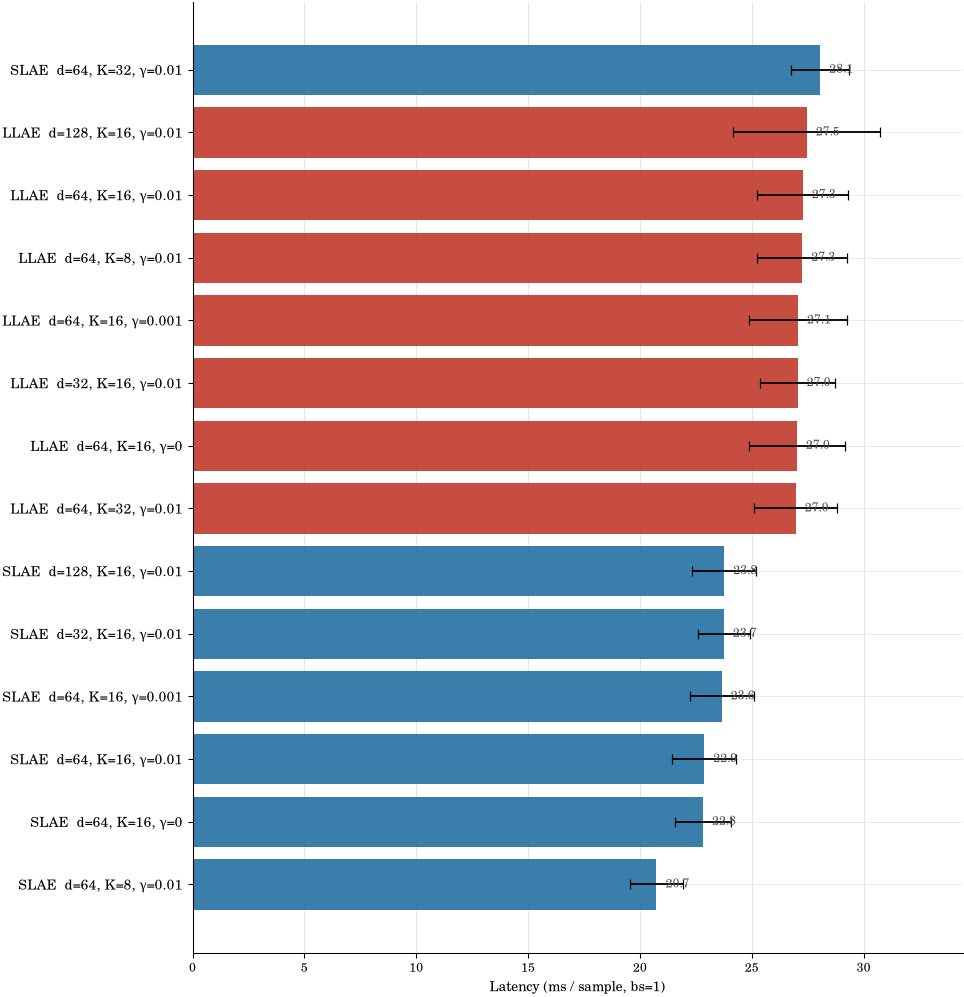

  ↳ article/images/ae_bench_latency.pdf


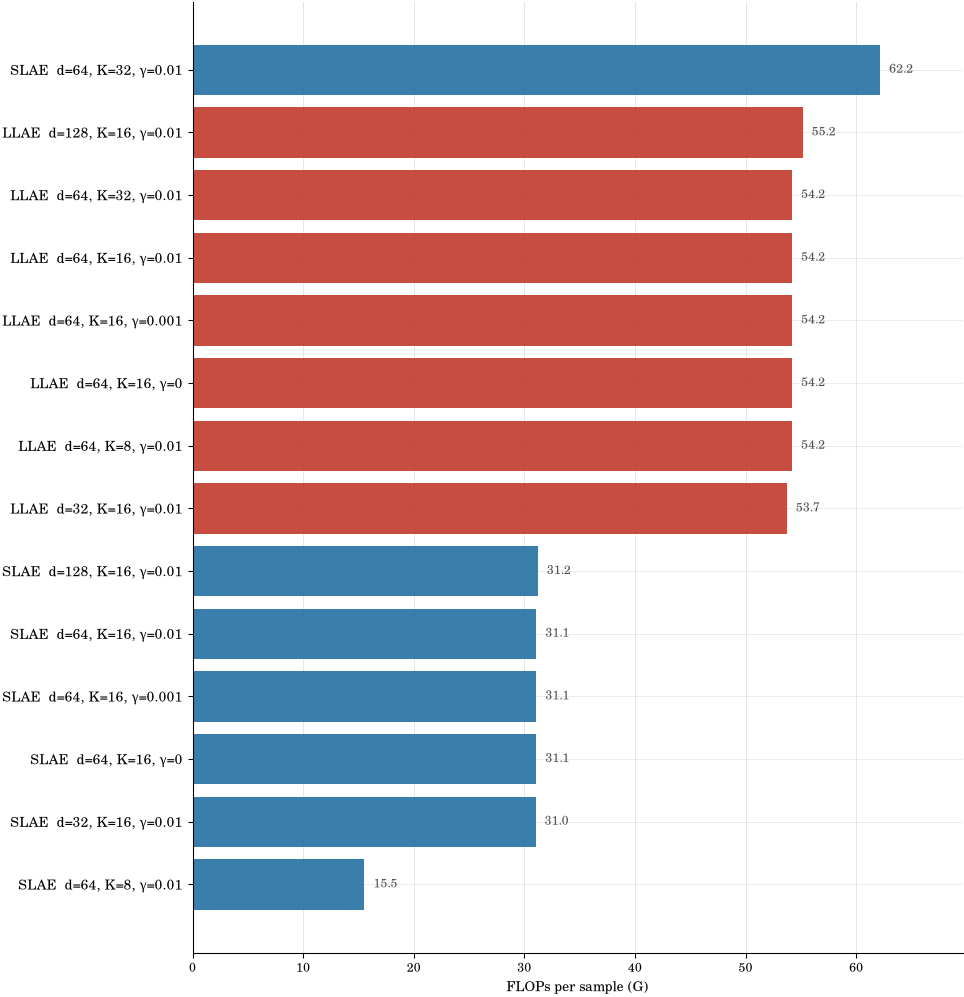

  ↳ article/images/ae_bench_flops.pdf


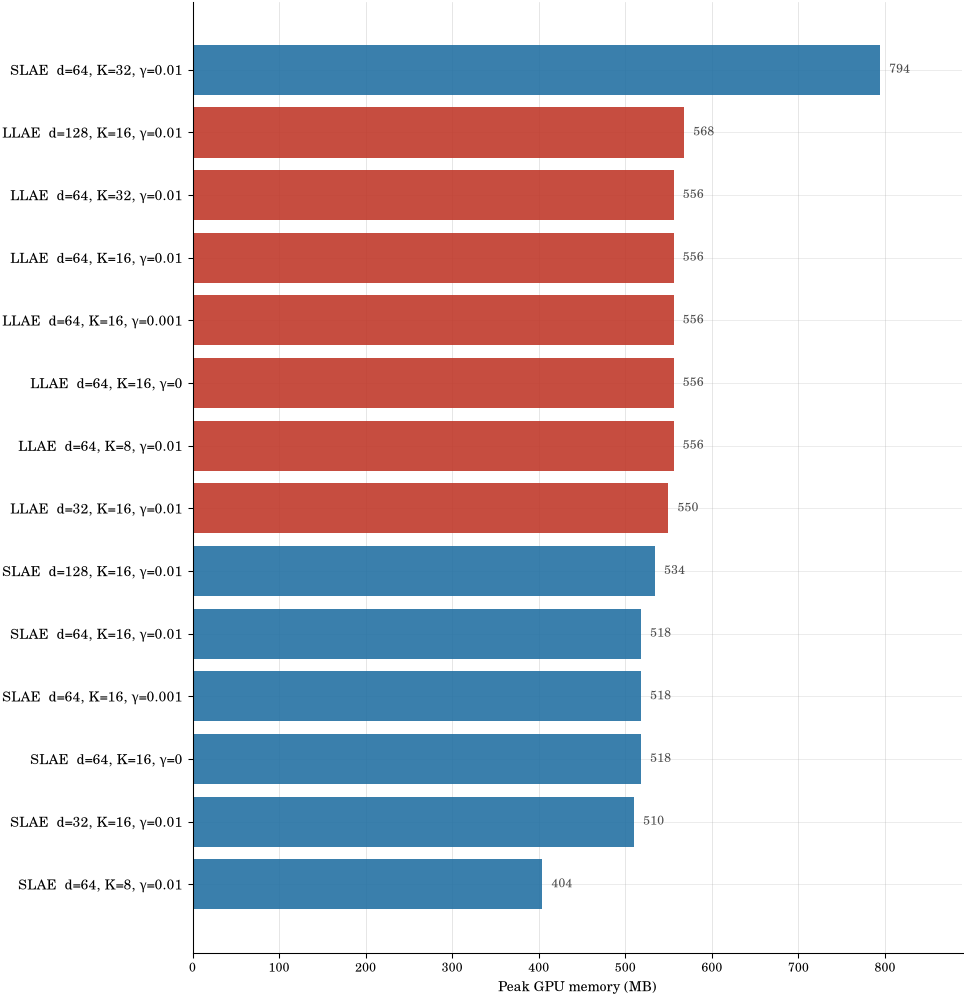

  ↳ article/images/ae_bench_memory.pdf


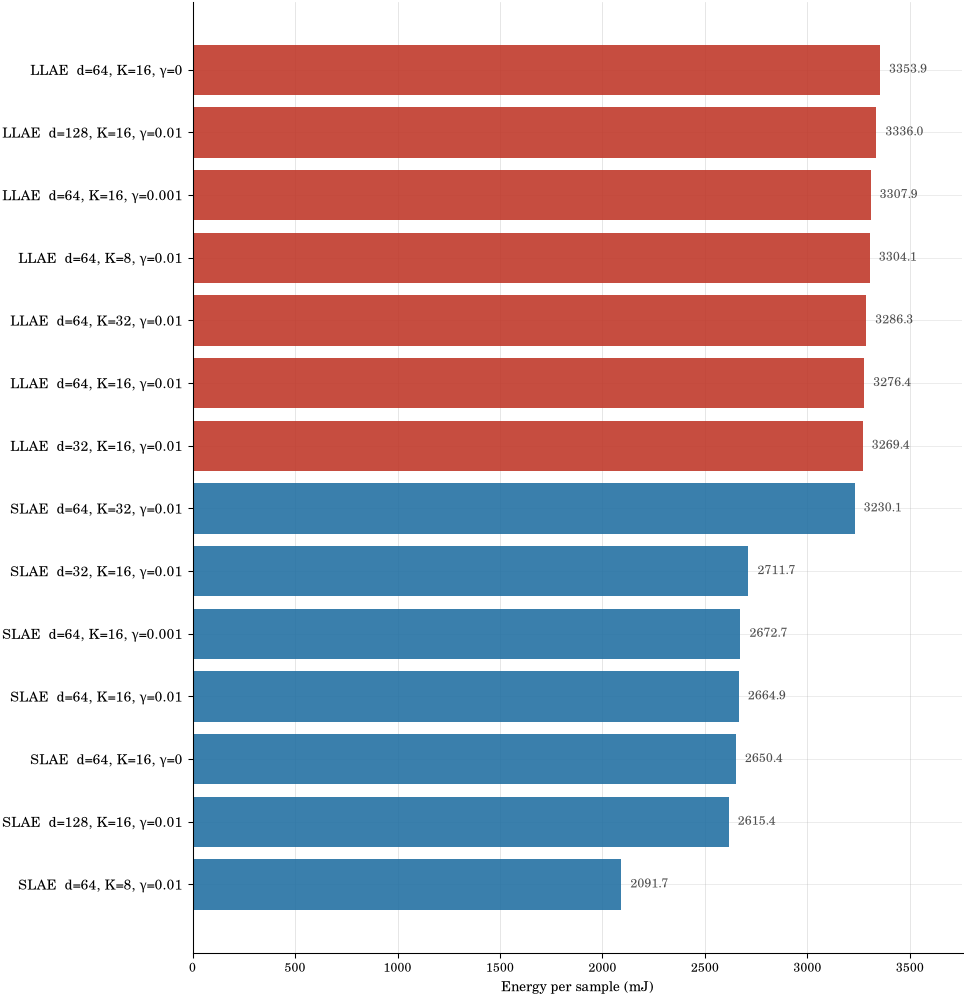

  ↳ article/images/ae_bench_energy.pdf


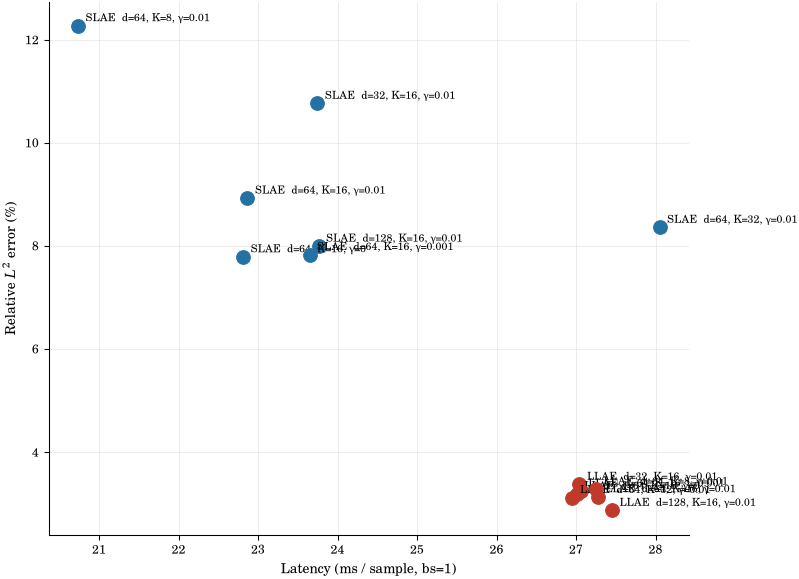

  ↳ article/images/ae_cost_latency.pdf


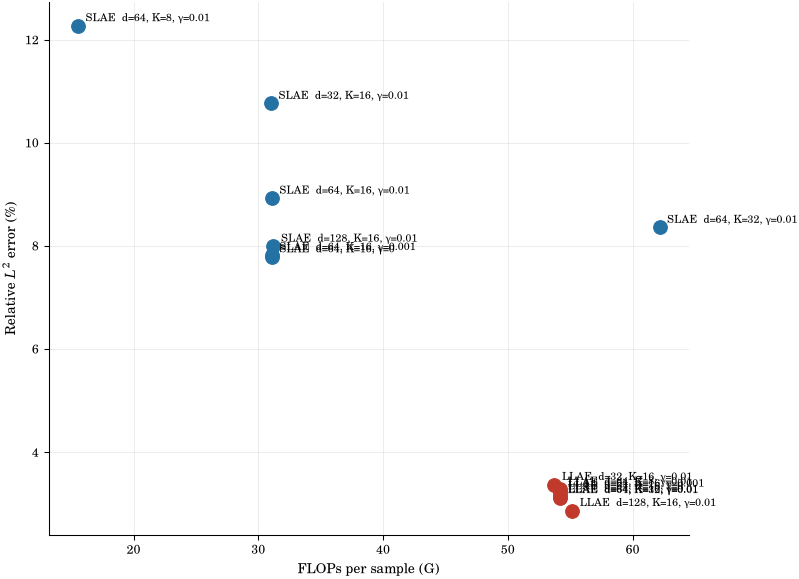

  ↳ article/images/ae_cost_flops.pdf


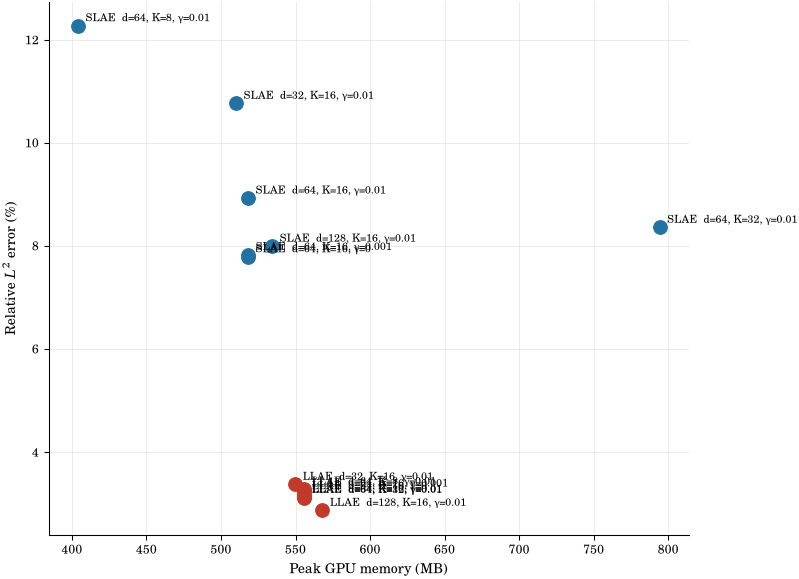

  ↳ article/images/ae_cost_memory.pdf


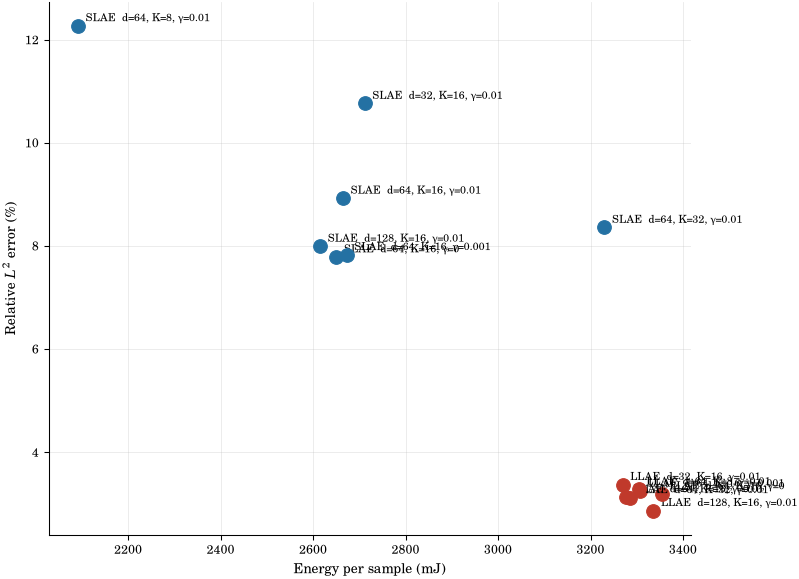

  ↳ article/images/ae_cost_energy.pdf


['cost_latency', 'cost_flops', 'cost_memory', 'cost_energy']

In [19]:
# Une figure par metrique (latence, FLOPs, memoire, energie), plus le nuage
# precision/cout correspondant. Voir notebooks/benchmark.py.
def _bench_color(n):
    return colors['llae' if n.startswith('llae') else 'slae']

benchmark.table(bench, label_of=_pretty_name)

benchmark.figures(bench, label_of=_pretty_name, color_of=_bench_color, device=device)

_acc = {n: float(np.median(results[n])) for n in results if n in bench}
benchmark.scatter(bench, _acc, label_of=_pretty_name, color_of=_bench_color,
                  device=device, ylabel=figstyle.LABELS['l2rel'])
